<a href="https://colab.research.google.com/github/beatrizalbiac/Neural-networks-and-deep-learning-group-project/blob/main/notebooks/basenotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ghqSrqFLA6WCAFrojYHF")
project = rf.workspace("volleyballyolo").project("volleyballyolo")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 63.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to VolleyBallYolo-1 in yolov11:: 100%|██████████| 622/622 [00:00<00:00, 6972.46it/s]


In [ ]:
!find /content -name "data.yaml"

/content/VolleyBallYolo-1/data.yaml


In [ ]:
!cat /content/VolleyBallYolo-1/data.yaml


train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['ball', 'person']

roboflow:
  workspace: volleyballyolo
  project: volleyballyolo
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/volleyballyolo/volleyballyolo/dataset/1

In [ ]:
# Instalar ultralytics (YOLO)
!pip install ultralytics

from ultralytics import YOLO
import yaml

# Ver cuántas imágenes tiene cada split
!find /content/VolleyBallYolo-1/train/images -name "*.jpg" | wc -l
!find /content/VolleyBallYolo-1/valid/images -name "*.jpg" | wc -l
!find /content/VolleyBallYolo-1/test/images -name "*.jpg" | wc -l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 8.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
267
25
13


In [ ]:
from ultralytics import YOLO

# Cargamos YOLOv11 preentrenado (transfer learning)
model = YOLO("yolo11n.pt")

# Entrenamos
results = model.train(
    data="/content/VolleyBallYolo-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="volleyball_detector",
    pretrained=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/VolleyBallYolo-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=volleyball_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask


image 1/13 /content/VolleyBallYolo-1/test/images/13_jpg.rf.82a2784d71edd80f50a624772fd606b3.jpg: 640x640 1 ball, 7 persons, 13.5ms
image 2/13 /content/VolleyBallYolo-1/test/images/159_png.rf.878a89205b8699c80fe4270b119f21fc.jpg: 640x640 15 persons, 15.9ms
image 3/13 /content/VolleyBallYolo-1/test/images/304_png.rf.d8cf9b5a25e214f40ed004a7d3c80ec2.jpg: 640x640 1 ball, 13 persons, 12.5ms
image 4/13 /content/VolleyBallYolo-1/test/images/32_jpg.rf.60036f321bb0f9125e0469176ad36642.jpg: 640x640 1 ball, 12 persons, 12.9ms
image 5/13 /content/VolleyBallYolo-1/test/images/484_png.rf.a8b1e3589f1f1b2bafa03fd40ba75586.jpg: 640x640 15 persons, 13.6ms
image 6/13 /content/VolleyBallYolo-1/test/images/486_png.rf.d2bb575e1df122ecff814c3e503ae9af.jpg: 640x640 11 persons, 12.9ms
image 7/13 /content/VolleyBallYolo-1/test/images/509_png.rf.66c31a1323ff708de2f4da74731c277e.jpg: 640x640 13 persons, 15.2ms
image 8/13 /content/VolleyBallYolo-1/test/images/518_png.rf.425590d2720dd212ada0431d83f83d81.jpg: 640x6

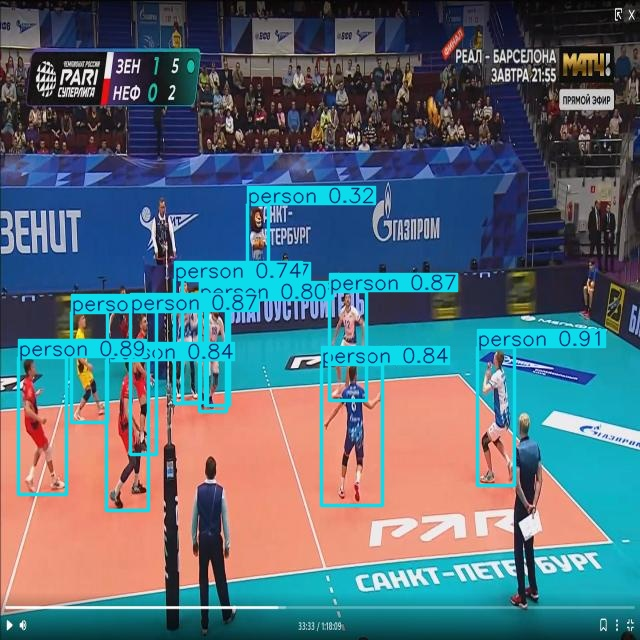

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Cargar el mejor modelo entrenado
model = YOLO("/content/runs/detect/volleyball_detector/weights/best.pt")

# Inferencia sobre imágenes de test
results = model.predict(
    source="/content/VolleyBallYolo-1/test/images",
    conf=0.3,
    save=True,
    name="test_predictions"
)

# Mostrar una imagen con las detecciones
import glob
imgs = glob.glob("/content/runs/detect/test_predictions/*.jpg")
img = cv2.imread(imgs[0])
cv2_imshow(img)

In [ ]:
import os
print(os.path.exists("/content/VolleyBallYolo-1/data.yaml"))
print(os.path.exists("/content/runs/detect/volleyball_detector/weights/best.pt"))

True
True


In [ ]:
!pip install gradio ultralytics
!apt-get install -y ffmpeg

import gradio as gr
from ultralytics import YOLO
import cv2
import numpy as np
import subprocess
import glob
import os
import shutil
from PIL import Image

model = YOLO("/content/runs/detect/volleyball_detector/weights/best.pt")

def run_detection_video(video_path, conf_threshold):
    if video_path is None:
        return None, "No video loaded"

    out_dir = "/content/runs/gradio_out"
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)

    results = model.predict(
        source=video_path,
        conf=conf_threshold,
        save=True,
        project="/content/runs",
        name="gradio_out",
        imgsz=640,
        verbose=False
    )

    all_videos = glob.glob("/content/runs/gradio_out/*.mp4") + \
                 glob.glob("/content/runs/gradio_out/*.avi")

    if not all_videos:
        return None, "Error: no se generó vídeo de salida"

    raw_path = all_videos[-1]
    fixed_path = "/content/output_fixed.mp4"

    subprocess.run([
        "ffmpeg", "-y", "-i", raw_path,
        "-vcodec", "libx264",
        "-crf", "23",
        "-preset", "fast",
        fixed_path
    ], capture_output=True)

    if not os.path.exists(fixed_path):
        return None, "Error en re-encoding"

    total_detections = sum(len(r.boxes) for r in results)
    total_frames = len(results)
    avg = total_detections / max(total_frames, 1)

    stats = f"Frames procesados: {total_frames}\n"
    stats += f"Detecciones totales: {total_detections}\n"
    stats += f"Media por frame: {avg:.1f}"

    return fixed_path, stats

def start_training(epochs, lr, batch):
    try:
        model_train = YOLO("yolo11n.pt")
        results = model_train.train(
            data="/content/VolleyBallYolo-1/data.yaml",
            epochs=int(epochs),
            lr0=float(lr),
            batch=int(batch),
            imgsz=640,
            name="volleyball_gradio",
            verbose=False
        )
        map50 = results.results_dict.get("metrics/mAP50(B)", "N/A")
        map50_95 = results.results_dict.get("metrics/mAP50-95(B)", "N/A")
        return f"✅ Training complete!\nmAP50: {map50}\nmAP50-95: {map50_95}"
    except Exception as e:
        return f"❌ Error: {str(e)}"

def vlm_respond(image, question, history):
    if image is None:
        history.append((question, "⚠️ Please upload an image first."))
        return history, ""
    if not question:
        history.append(("(empty)", "⚠️ Please ask a question."))
        return history, ""

    img_array = np.array(image)
    results = model.predict(img_array, conf=0.3, verbose=False)
    detections = results[0].boxes
    counts = {}
    for box in detections:
        label = model.names[int(box.cls[0])]
        counts[label] = counts.get(label, 0) + 1

    desc = ", ".join([f"{v} {k}" for k, v in counts.items()]) if counts else "no detections"
    answer = f"In this scene I can detect: {desc}. (Full VLM coming soon)"

    history.append((question, answer))
    return history, ""

with gr.Blocks(title="VolleyVision AI", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏐 VolleyVision AI — Sports Analysis System")

    with gr.Tabs():

        with gr.Tab("🎬 Video Detection"):
            with gr.Row():
                with gr.Column():
                    input_video = gr.Video(label="Upload Video")
                    conf_slider_vid = gr.Slider(0.1, 1.0, value=0.3, label="Confidence Threshold")
                    detect_btn_vid = gr.Button("▶ Run Detection", variant="primary")
                with gr.Column():
                    output_video = gr.Video(label="Video con Detecciones")
                    output_text_vid = gr.Textbox(label="Results", lines=5)

            detect_btn_vid.click(
                fn=run_detection_video,
                inputs=[input_video, conf_slider_vid],
                outputs=[output_video, output_text_vid]
            )

        with gr.Tab("🧠 Training"):
            with gr.Row():
                with gr.Column():
                    epochs_input = gr.Number(value=50, label="Epochs")
                    lr_input = gr.Number(value=0.001, label="Learning Rate")
                    batch_input = gr.Number(value=16, label="Batch Size")
                    train_btn = gr.Button("▶ Start Training", variant="primary")
                with gr.Column():
                    train_output = gr.Textbox(label="Training Log", lines=10)

            train_btn.click(
                fn=start_training,
                inputs=[epochs_input, lr_input, batch_input],
                outputs=train_output
            )

        with gr.Tab("💬 VLM Assistant"):
            with gr.Row():
                with gr.Column():
                    vlm_image = gr.Image(label="Scene Image", type="pil")
                with gr.Column():
                    chatbot = gr.Chatbot(label="Scene Q&A", height=300)
                    vlm_input = gr.Textbox(
                        label="Ask about the scene",
                        placeholder="What is happening in this scene?"
                    )
                    vlm_btn = gr.Button("Ask", variant="primary")

            vlm_btn.click(
                fn=vlm_respond,
                inputs=[vlm_image, vlm_input, chatbot],
                outputs=[chatbot, vlm_input]
            )

demo.launch(share=True, max_file_size="500mb")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c93dbc243356a2949.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
